# Collection Technique Comparison — Which Method Best Captures Crystal Signal?
### SSA — Diamond I11 Beamline | Static Trial, 50mm

**Purpose:** A clean, focused restart — separate from the background-subtraction notebook — to answer one question: **which collection technique gives the best crystal-capture signal (spot_density), independent of the 1000ms static-snapshot work used to validate the subtraction method itself?**

The 1000ms static snapshots were the right tool for validating calibration, background matching, and subtraction — they are NOT meant to represent real flowing-beamtime collection technique. This notebook answers that separate, real question directly.

**Techniques compared** (all at 50mm, from the tracker):
- Single-shot, no stage movement: 250ms, 500ms, 1000ms, 2-3s, long (30s/60s)
- Swish (old-style): stage moves between shots, discrete repeats
- Snapshot-during-movement (new): 0.25s (250ms, large frame) and 0.1s (100ms, small frame) snapshot series while the stage moves continuously

**Metric:** spot_density / crystal_score (Bragg-spot detection), NOT FEP-ring SNR — this is a crystal-capture question, not a background-noise question.

---
**Run cells one at a time, top to bottom.**

---
## Step 0 — Paths, tracker, and BOTH geometries (big frame + small frame)

In [7]:
import os, glob
import numpy as np
import pandas as pd

# ══════════════════════════════════════════════════════════════
# PATHS — confirm/update these before running
# ══════════════════════════════════════════════════════════════

MODULE_DIR   = r"C:/Users/ezxsa27/I11_PXRD_SSA/I11_PXRD_processing_scripts/FEP_Subtraction/"
import sys
sys.path.insert(0, MODULE_DIR)

RAW_ROOT     = r"E:/static/raw/raw_D1+2"          # <-- update if needed
OUTPUT_DIR   = r"E:/static/Corrected_2D/Technique_Comparison/"
TRACKER_PATH = r"C:/Users/ezxsa27/OneDrive - The University of Nottingham/Nottingham/Year 3 (June 26 -)/Static Trials/I11_Static_Trials_Tracker_CLEAN.xlsx"  # <-- update

# Big frame (2881x2880) geometry - Day 1, already validated
PONI_50MM       = r"E:/static/raw/Calib/Calib_50.poni"        # <-- update
MASK_PATH       = r"E:/static/raw/Calib/Calib_50_mask.npy"          # <-- update

# Small frame (1441x1440) geometry - for the 100ms-snapshot-with-swish technique
PONI_50MM_SMALL = r"E:/static/raw/Calib/Calib_50_smallframe.poni"       # <-- update
MASK_PATH_SMALL = r"E:/static/raw/Calib/Calib_50_smallframe_mask.npy"   # <-- update

os.makedirs(OUTPUT_DIR, exist_ok=True)

tracker = pd.read_excel(TRACKER_PATH, sheet_name="Condition Tracker", header=6)
tracker.columns = [str(c).strip() for c in tracker.columns]
tracker["Sample code"]   = tracker["Sample code"].astype(str).str.strip()
tracker["Exposure code"] = tracker["Exposure code"].astype(str).str.strip()
tracker["Data logged?"]  = tracker["Data logged?"].astype(str).str.strip().str.upper()

tracker_clean = tracker[
    (tracker["Data logged?"] == "Y") &
    (tracker["Exclude?"].isna())
]
tracker_50 = tracker_clean[tracker_clean["Distance (mm)"] == 50]

def collection_numbers_for(sample_code, distance=50, exposure_code=None):
    sub = tracker_clean[
        (tracker_clean["Sample code"] == sample_code) &
        (tracker_clean["Distance (mm)"] == distance)
    ]
    if exposure_code is not None:
        sub = sub[sub["Exposure code"] == exposure_code]
    return sub["Collection #(s)"].dropna().astype(int).astype(str).tolist()

def extract_number(fp):
    stem = os.path.splitext(os.path.basename(fp))[0]
    for part in reversed(stem.replace("-", "_").split("_")):
        if part.isdigit():
            return part
    return ""

all_raw_files = sorted(glob.glob(os.path.join(RAW_ROOT, "*.nxs")))
all_numbers = {f: extract_number(f) for f in all_raw_files}

def files_for_numbers(numbers):
    wanted = set(numbers)
    return sorted([f for f, n in all_numbers.items() if n in wanted])

print(f"Raw files found: {len(all_raw_files)}")
print(f"Gly_AS_tri rows @ 50mm (all exposure codes): {len(tracker_50[tracker_50['Sample code']=='Gly_AS_tri'])}")
print("\nExposure codes present for Gly_AS_tri @ 50mm:")
print(tracker_50[tracker_50['Sample code']=='Gly_AS_tri']['Exposure code'].value_counts())

Raw files found: 199
Gly_AS_tri rows @ 50mm (all exposure codes): 37

Exposure codes present for Gly_AS_tri @ 50mm:
Exposure code
1000ms                              11
Swish                               10
0.25 (250ms) snapshot with swish     4
0.1 (100ms) snapshot with swish      4
3s                                   3
long                                 2
250ms                                1
500ms                                1
2-3s                                 1
Name: count, dtype: int64


In [8]:
from fep_subtraction_2d_i11 import (
    beam_center_px_from_poni,
    FrameMetricConfig,
    evaluate_frame_with_status,
    _load_pixium_frame,
)

# --- Big frame geometry ---
cy_big, cx_big = beam_center_px_from_poni(PONI_50MM)
mask_big = np.load(MASK_PATH)
print(f"Big frame  ({mask_big.shape}): beam centre row={cy_big:.2f} col={cx_big:.2f}, "
      f"mask {100*mask_big.sum()/mask_big.size:.2f}% masked")

# --- Small frame geometry ---
cy_small, cx_small = beam_center_px_from_poni(PONI_50MM_SMALL)
mask_small = np.load(MASK_PATH_SMALL)
print(f"Small frame ({mask_small.shape}): beam centre row={cy_small:.2f} col={cx_small:.2f}, "
      f"mask {100*mask_small.sum()/mask_small.size:.2f}% masked")

# Two separate configs - ring radius will be auto-detected per config
# the first time each is used (different geometry = different ring radius)
cfg_big = FrameMetricConfig(beam_center_px=(cy_big, cx_big), detect_fep_ring=True)
cfg_small = FrameMetricConfig(beam_center_px=(cy_small, cx_small), detect_fep_ring=True)

print("\n✅ Both geometries loaded. Ready for Step 1.")

Big frame  ((2881, 2880)): beam centre row=1442.20 col=1441.66, mask 0.66% masked
Small frame ((1441, 1440)): beam centre row=719.20 col=720.56, mask 0.82% masked

✅ Both geometries loaded. Ready for Step 1.


---
## Step 1 — Evaluate spot_density for every Gly_AS_tri frame, across ALL techniques

Runs the calibrated classifier on every confirmed Gly_AS_tri collection at 50mm, using whichever geometry (big frame vs small frame) matches each file's actual frame size — handled automatically per-frame below, so the two 'snapshot with swish' technique variants get evaluated correctly.

In [13]:
gly_rows_all = tracker_50[tracker_50["Sample code"] == "Gly_AS_tri"].copy()

technique_results = []

for exposure_code, group in gly_rows_all.groupby("Exposure code"):
    numbers = group["Collection #(s)"].dropna().astype(int).astype(str).tolist()
    files = files_for_numbers(numbers)
    if not files:
        print(f"⚠️  No files matched for exposure_code={exposure_code!r} — skipping")
        continue

    for fp in files:
        try:
            probe = _load_pixium_frame(fp)
        except Exception as exc:
            print(f"⚠️  {os.path.basename(fp)}: failed to load ({exc}) — skipping")
            continue

        # Determine how many sub-frames this file actually holds
        n_subframes = probe.shape[0] if probe.ndim == 3 else 1

        for sub_idx in range(n_subframes):
            frame_shape = probe.shape[-2:]
            if frame_shape == mask_big.shape:
                mask_use, cfg_use, frame_kind = mask_big, cfg_big, "big"
            elif frame_shape == mask_small.shape:
                mask_use, cfg_use, frame_kind = mask_small, cfg_small, "small"
            else:
                print(f"⚠️  {os.path.basename(fp)}: unexpected shape {frame_shape} — skipping")
                continue

            metrics, status = evaluate_frame_with_status(
                fp, frame_index=sub_idx, mask=mask_use, config=cfg_use
            )
            if status.status != "ok":
                print(f"  skipped {os.path.basename(fp)} frame {sub_idx}: {status.error}")
                continue

            technique_results.append({
                "exposure_code": exposure_code,
                "frame_kind": frame_kind,
                "file": os.path.basename(fp),
                "sub_frame": sub_idx,
                "n_subframes_in_file": n_subframes,
                "spot_density": status.spot_density,
                "crystal_score": status.crystal_score,
                "auto_class": status.auto_class,
                "fep_ring_r": status.fep_ring_r,
            })

df_technique = pd.DataFrame(technique_results)
print(f"\n✅ Evaluated {len(df_technique)} individual sub-frames across {df_technique['exposure_code'].nunique()} technique(s).")
print(df_technique.groupby("exposure_code")["n_subframes_in_file"].agg(["count", "mean"]))

⚠️  i11-1-145401.nxs: failed to load (No 2D dataset found in i11-1-145401.nxs. Pass detector_path explicitly.) — skipping

✅ Evaluated 100 individual sub-frames across 9 technique(s).
                                  count  mean
exposure_code                                
0.1 (100ms) snapshot with swish      48  12.0
0.25 (250ms) snapshot with swish     24   6.0
1000ms                               10   1.0
2-3s                                  1   1.0
250ms                                 1   1.0
3s                                    3   1.0
500ms                                 1   1.0
Swish                                10   1.0
long                                  2   1.0


---
## Step 2 — Rank techniques by spot_density

Summarised per technique. Higher mean spot_density = more/stronger Bragg signal captured on average. Also reports n (sample size) and total collection time where available, since a technique with very few frames deserves less confidence than one with many.

In [15]:
summary_technique = df_technique.groupby("exposure_code").agg(
    n_frames=("spot_density", "size"),
    mean_spot_density=("spot_density", "mean"),
    median_spot_density=("spot_density", "median"),
    max_spot_density=("spot_density", "max"),
    n_classified_crystal=("auto_class", lambda s: (s == "crystal").sum()),
).sort_values("mean_spot_density", ascending=False)

summary_technique["pct_hit"] = 100 * summary_technique["n_classified_crystal"] / summary_technique["n_frames"]
print(summary_technique)


                                  n_frames  mean_spot_density  \
exposure_code                                                   
2-3s                                     1           0.006287   
long                                     2           0.006149   
3s                                       3           0.005699   
Swish                                   10           0.005421   
1000ms                                  10           0.003433   
500ms                                    1           0.003353   
250ms                                    1           0.002610   
0.25 (250ms) snapshot with swish        24           0.001565   
0.1 (100ms) snapshot with swish         48           0.000784   

                                  median_spot_density  max_spot_density  \
exposure_code                                                             
2-3s                                         0.006287          0.006287   
long                                         0.006149      

In [12]:
fp = files_for_numbers(collection_numbers_for("Gly_AS_tri", exposure_code="0.25 (250ms) snapshot with swish"))[0]
frame = _load_pixium_frame(fp)
print("Shape:", frame.shape)
print("This means:", "single accumulated frame" if frame.ndim == 2 or frame.shape[0] == 1 else f"{frame.shape[0]} separate sub-frames stored")

Shape: (6, 2881, 2880)
This means: 6 separate sub-frames stored


In [16]:
print(df_technique[df_technique["frame_kind"] == "small"]["fep_ring_r"].describe())
print(df_technique[df_technique["frame_kind"] == "big"]["fep_ring_r"].describe())

count    48.000000
mean     91.562500
std       0.501328
min      91.000000
25%      91.000000
50%      92.000000
75%      92.000000
max      92.000000
Name: fep_ring_r, dtype: float64
count     52.000000
mean     188.903846
std        0.297678
min      188.000000
25%      189.000000
50%      189.000000
75%      189.000000
max      189.000000
Name: fep_ring_r, dtype: float64


Shape: (12, 1441, 1440)


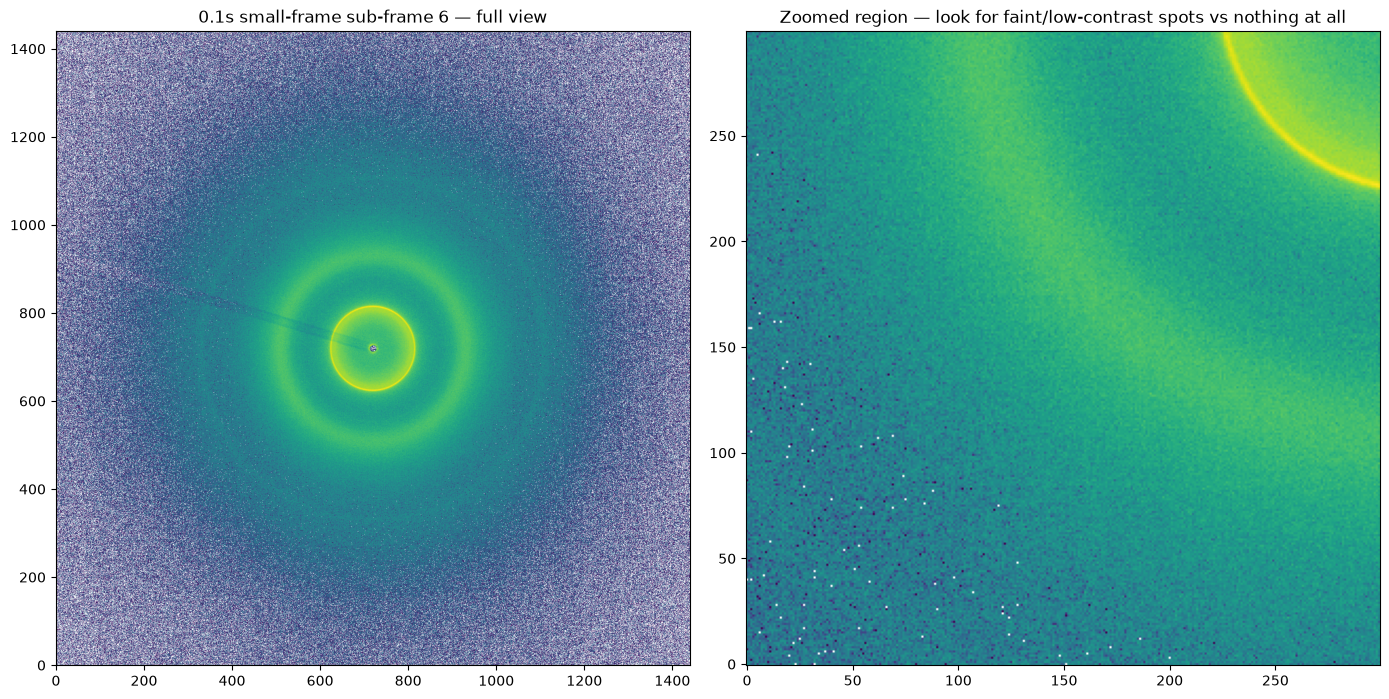

In [18]:
import matplotlib.pyplot as plt
fp = files_for_numbers(collection_numbers_for("Gly_AS_tri", exposure_code="0.1 (100ms) snapshot with swish"))[0]
frame = _load_pixium_frame(fp)
print("Shape:", frame.shape)

sub = frame[6]  # try a middle sub-frame

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
from matplotlib.colors import LogNorm
vmin = max(1, np.percentile(sub[sub>0], 1))
ax[0].imshow(sub, origin="lower", norm=LogNorm(vmin=vmin, vmax=sub.max()), cmap="viridis")
ax[0].set_title("0.1s small-frame sub-frame 6 — full view")

# Zoom into a region away from the beamstop/ring to look for faint, low-contrast spots
zoom = sub[400:700, 400:700]
ax[1].imshow(zoom, origin="lower", norm=LogNorm(vmin=vmin, vmax=zoom.max()), cmap="viridis")
ax[1].set_title("Zoomed region — look for faint/low-contrast spots vs nothing at all")
plt.tight_layout()
plt.show()

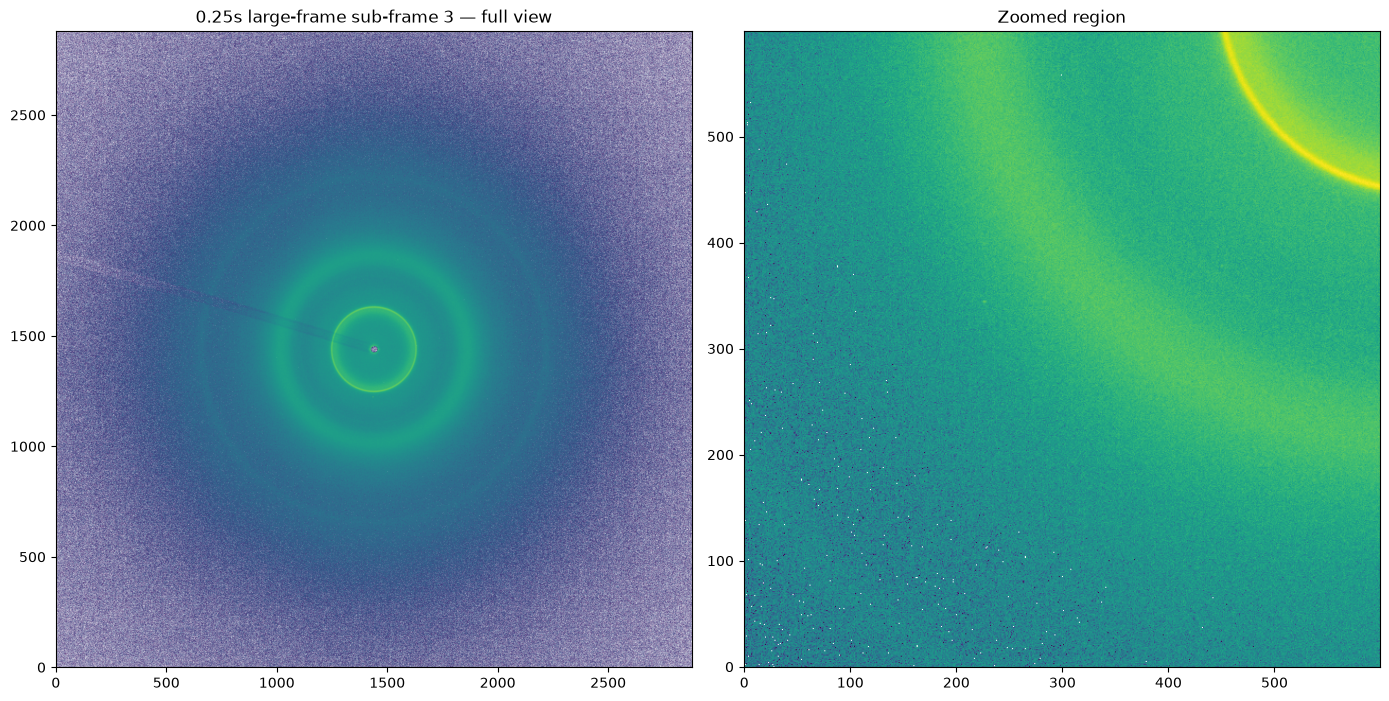

In [19]:
fp = files_for_numbers(collection_numbers_for("Gly_AS_tri", exposure_code="0.25 (250ms) snapshot with swish"))[0]
frame = _load_pixium_frame(fp)
sub = frame[3]

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
from matplotlib.colors import LogNorm
vmin = max(1, np.percentile(sub[sub>0], 1))
ax[0].imshow(sub, origin="lower", norm=LogNorm(vmin=vmin, vmax=sub.max()), cmap="viridis")
ax[0].set_title("0.25s large-frame sub-frame 3 — full view")
zoom = sub[800:1400, 800:1400]
ax[1].imshow(zoom, origin="lower", norm=LogNorm(vmin=vmin, vmax=zoom.max()), cmap="viridis")
ax[1].set_title("Zoomed region")
plt.tight_layout()
plt.show()


                file  spot_density  crystal_score
89  i11-1-145302.nxs      0.007319            1.0
90  i11-1-145303.nxs      0.005177            1.0
91  i11-1-145304.nxs      0.006232            1.0
92  i11-1-145305.nxs      0.004946            1.0
93  i11-1-145306.nxs      0.005862            1.0
94  i11-1-145307.nxs      0.005166            1.0
95  i11-1-145308.nxs      0.005767            1.0
96  i11-1-145309.nxs      0.006238            1.0
97  i11-1-145310.nxs      0.005764            1.0


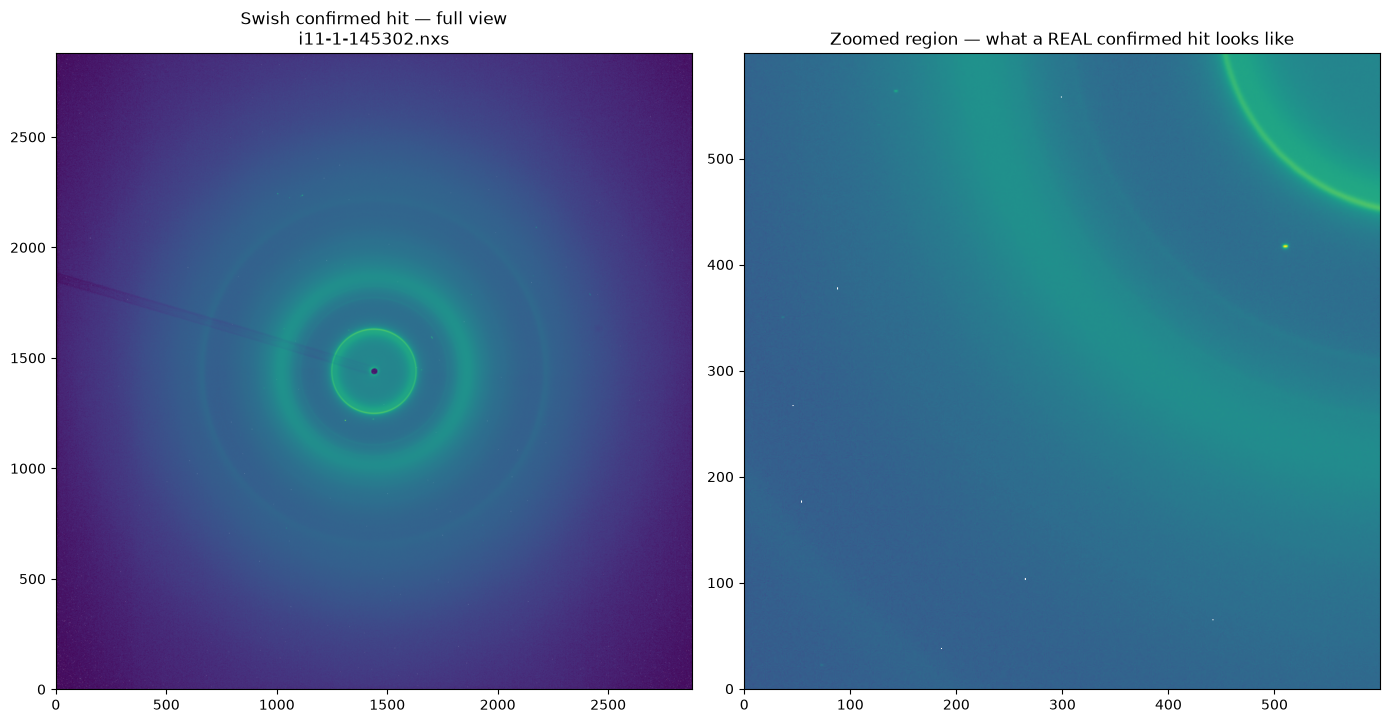

In [20]:
swish_hits = df_technique[(df_technique["exposure_code"] == "Swish") & (df_technique["auto_class"] == "crystal")]
print(swish_hits[["file", "spot_density", "crystal_score"]])

# Pick the first confirmed hit
fp = [f for f in files_for_numbers(collection_numbers_for("Gly_AS_tri", exposure_code="Swish"))
      if swish_hits.iloc[0]["file"].replace("i11-1-", "").replace(".nxs", "") in f][0]

frame = _load_pixium_frame(fp)
if frame.ndim == 3:
    frame = frame[0]

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
from matplotlib.colors import LogNorm
vmin = max(1, np.percentile(frame[frame>0], 1))
ax[0].imshow(frame, origin="lower", norm=LogNorm(vmin=vmin, vmax=frame.max()), cmap="viridis")
ax[0].set_title(f"Swish confirmed hit — full view\n{swish_hits.iloc[0]['file']}")

zoom = frame[800:1400, 800:1400]  # same zoom window as before, for fair comparison
ax[1].imshow(zoom, origin="lower", norm=LogNorm(vmin=vmin, vmax=zoom.max()), cmap="viridis")
ax[1].set_title("Zoomed region — what a REAL confirmed hit looks like")
plt.tight_layout()
plt.show()